In [2]:
# ============================================================
# CELL 1 — Run this FIRST to install all required libraries
# Only need to run this once. After it finishes, run Cell 2.
# ============================================================

import subprocess, sys

packages = [
    "torch",
    "torchvision",
    "numpy",
    "pandas",
    "pillow",
    "scikit-learn",
    "matplotlib",
    "tqdm",
]

print("Installing required packages...")
print("This may take 2-5 minutes the first time.\n")

for pkg in packages:
    print(f"  Installing {pkg}...", end=" ")
    sys.stdout.flush()
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("OK")
    else:
        print(f"FAILED — {result.stderr.strip()}")
    sys.stdout.flush()

print("\nAll done! Now run the next cell.")

Installing required packages...
This may take 2-5 minutes the first time.

  Installing torch... OK
  Installing torchvision... OK
  Installing numpy... OK
  Installing pandas... OK
  Installing pillow... OK
  Installing scikit-learn... OK
  Installing matplotlib... OK
  Installing tqdm... OK

All done! Now run the next cell.


In [9]:
# ============================================================
# Movie Genre Classifier — ResNet50
# ============================================================
# HOW TO USE:
#   1. Make sure movies_dataset.csv and posters/ folder are in
#      the SAME folder as this file
#   2. Run this cell — it will train automatically
#   3. After training use load_and_predict("poster.jpg")
# ============================================================

import os, sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ============================================================
# CONFIG  —  change these if needed
# ============================================================
CSV_PATH          = "movies_dataset.csv"
POSTERS_DIR       = Path("posters")
MODEL_SAVE        = "movie_genre_resnet50.pth"
CLASSES_SAVE      = "genre_classes.txt"

NUM_EPOCHS        = 6       # max epochs; early stopping will cut this short
BATCH_SIZE        = 32       # safe for CPU and GPU
IMG_SIZE          = 160      # smaller = faster training
LR                = 3e-4
WEIGHT_DECAY      = 1e-4
SAMPLES_PER_CLASS = 500      # sweet spot — big genres undersample, small ones barely oversample
PATIENCE          = 2        # stop if no improvement for 4 epochs in a row

# All 10 genres — each has enough real posters for 250 samples
# Oversampling ratio is small (max 1.4x for Romance 178->250)
KEEP_GENRES = [
    "Action",           # 1102 real  -> undersample to 250
    "Drama",            # 1068 real  -> undersample to 250
    "Comedy",           #  864 real  -> undersample to 250
    "Horror",           #  528 real  -> undersample to 250
    "Animation",        #  452 real  -> undersample to 250
    "Adventure",        #  392 real  -> undersample to 250
    "Thriller",         #  301 real  -> undersample to 250
    "Crime",            #  261 real  -> undersample to 250
    "Science Fiction",  #  229 real  -> oversample x1.1 (barely)
    "Romance",          #  178 real  -> oversample x1.4 (mild)
]


# ============================================================
# STEP 1 — BALANCE THE DATASET
# ============================================================
def balance_dataset(csv_path):
    SEP = "=" * 60

    print(SEP)
    print("  STEP 1 — Balancing the dataset")
    print(SEP)
    sys.stdout.flush()

    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()

    # Take only the FIRST/PRIMARY genre per movie
    df["main_genre"] = df["genres"].apply(
        lambda x: str(x).split(",")[0].strip()
    )

    counts = df["main_genre"].value_counts()

    print("\n  BEFORE balancing (original CSV):")
    for genre, n in counts.items():
        bar    = "#" * min(35, n // 30)
        kept   = "  <-- KEEP" if genre in KEEP_GENRES else "  <-- DROP"
        print(f"    {genre:<20} {n:>5}  {bar}{kept}")
    sys.stdout.flush()

    # Keep only genres in KEEP_GENRES list
    df = df[df["main_genre"].isin(KEEP_GENRES)].copy()

    # Make every class EXACTLY SAMPLES_PER_CLASS rows
    parts = []
    for genre in KEEP_GENRES:
        g = df[df["main_genre"] == genre]
        n = len(g)
        if n == 0:
            print(f"  WARNING: No data found for genre '{genre}' — skipping")
            continue
        if n >= SAMPLES_PER_CLASS:
            # Undersample
            parts.append(g.sample(n=SAMPLES_PER_CLASS, random_state=42))
        else:
            # Oversample: repeat until we have enough, then trim
            reps  = (SAMPLES_PER_CLASS // n) + 1
            g_big = pd.concat([g] * reps, ignore_index=True)
            parts.append(g_big.sample(n=SAMPLES_PER_CLASS, random_state=42))

    df_bal = (pd.concat(parts, ignore_index=True)
              .sample(frac=1, random_state=42)
              .reset_index(drop=True))

    df_bal.to_csv("balanced_movies.csv", index=False)
    classes = sorted(df_bal["main_genre"].unique().tolist())

    # Verify every class is exactly equal
    after  = df_bal["main_genre"].value_counts().sort_index()
    ok     = all(v == SAMPLES_PER_CLASS for v in after.values)
    unit   = max(1, SAMPLES_PER_CLASS // 20)

    print(f"\n  AFTER balancing  —  {'ALL EQUAL' if ok else 'CHECK FAILED'}:")
    for genre, n in after.items():
        bar   = "#" * (n // unit)
        check = "OK" if n == SAMPLES_PER_CLASS else f"ERROR got {n}"
        print(f"    {genre:<20} {n:>5}  {bar}  {check}")

    print(f"\n  Total samples : {len(df_bal)}")
    print(f"  Classes       : {len(classes)}")
    print(f"  Each class    : exactly {SAMPLES_PER_CLASS} samples")
    print(SEP)
    sys.stdout.flush()

    return df_bal, classes


# ============================================================
# STEP 2 — TRANSFORMS
# ============================================================
def get_transforms(is_train):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if is_train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


# ============================================================
# STEP 3 — DATASET
# ============================================================
class PosterDataset(Dataset):
    def __init__(self, df, img_dir, class_to_idx, transform=None):
        self.transform    = transform
        self.class_to_idx = class_to_idx
        self.img_dir      = Path(img_dir)
        self.samples      = []   # list of (image_path, label_index)

        # Build fast lowercase lookup
        disk = {}
        if self.img_dir.exists():
            disk = {f.lower(): f for f in os.listdir(self.img_dir)}

        missing = 0
        for _, row in df.iterrows():
            genre = row["main_genre"]
            if genre not in class_to_idx:
                continue

            # Try {id}.jpg first
            img_id = str(row["id"]).strip().lower()
            key1   = img_id if img_id.endswith(".jpg") else img_id + ".jpg"

            # Fallback: poster_local hash filename
            key2 = None
            if "poster_local" in df.columns and pd.notna(row.get("poster_local")):
                key2 = Path(str(row["poster_local"])).name.lower()

            found = False
            for key in [k for k in [key1, key2] if k]:
                if key in disk:
                    self.samples.append(
                        (self.img_dir / disk[key], class_to_idx[genre])
                    )
                    found = True
                    break
            if not found:
                missing += 1

        print(f"    Loaded {len(self.samples):,} images  |  {missing:,} not found on disk")
        sys.stdout.flush()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (100, 100, 100))
        if self.transform:
            img = self.transform(img)
        return img, label


# ============================================================
# STEP 4 — RESNET50 MODEL
# ============================================================
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Fine-tune all layers
    for p in model.parameters():
        p.requires_grad = True
    # Replace final layer to match our number of genres
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model


# ============================================================
# HELPERS
# ============================================================
def fmt_time(secs):
    secs = max(0, int(secs))
    h, r = divmod(secs, 3600)
    m, s = divmod(r, 60)
    if h:
        return f"{h}h {m:02d}m {s:02d}s"
    return f"{m}m {s:02d}s" if m else f"{s}s"


def save_chart(history):
    ep = list(range(1, len(history["tl"]) + 1))
    if len(ep) < 1:
        return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ResNet50 — Training Progress", fontsize=13, fontweight="bold")

    ax1.plot(ep, history["tl"], "o-",  color="#E06C75", lw=2, ms=5, label="Train Loss")
    ax1.plot(ep, history["vl"], "s--", color="#61AFEF", lw=2, ms=5, label="Val Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_xticks(ep)

    ax2.plot(ep, history["ta"], "o-",  color="#98C379", lw=2, ms=5, label="Train Acc")
    ax2.plot(ep, history["va"], "s--", color="#C678DD", lw=2, ms=5, label="Val Acc")
    if history["va"]:
        best_e = int(np.argmax(history["va"])) + 1
        best_a = max(history["va"])
        ax2.axvline(best_e, color="gold", lw=1.5, ls=":",
                    label=f"Best: Epoch {best_e}  ({best_a:.1f}%)")
    ax2.set_title("Accuracy per Epoch")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_xticks(ep); ax2.set_ylim(0, 100)

    plt.tight_layout()
    plt.savefig("training_progress.png", dpi=120, bbox_inches="tight")
    plt.close()


# ============================================================
# STEP 5 — TRAINING LOOP
# ============================================================
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                device, num_epochs, patience):

    history       = {"tl": [], "vl": [], "ta": [], "va": []}
    best_val_acc  = 0.0
    no_improve    = 0
    total_batches = num_epochs * len(train_loader)
    done_batches  = 0
    t0            = time.time()

    SEP = "=" * 60
    print(SEP)
    print("  STEP 5 — Training")
    print(SEP)
    print(f"  Device          : {device}")
    print(f"  Max epochs      : {num_epochs}  (early stopping at {patience} bad epochs)")
    print(f"  Batches/epoch   : {len(train_loader)}")
    print(f"  Batch size      : {BATCH_SIZE}")
    print(f"  Image size      : {IMG_SIZE} x {IMG_SIZE}")
    print(f"  Total batches   : {total_batches}")
    print(SEP)
    sys.stdout.flush()

    for epoch in range(num_epochs):
        ep_start = time.time()

        # ── TRAIN ────────────────────────────────────────────
        model.train()
        t_loss = t_correct = t_total = 0

        for bi, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            _, preds   = torch.max(out, 1)
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (preds == labels).sum().item()
            t_total   += imgs.size(0)
            done_batches += 1

            # Print a progress line every 10 batches AND at the last batch
            if (bi + 1) % 10 == 0 or (bi + 1) == len(train_loader):
                run_loss = t_loss / t_total
                run_acc  = 100.0 * t_correct / t_total
                elapsed  = time.time() - t0
                speed    = done_batches / elapsed if elapsed > 0 else 1
                eta      = (total_batches - done_batches) / speed

                pct    = 100.0 * (bi + 1) / len(train_loader)
                filled = int(pct / 2)             # bar is 50 chars wide
                bar    = "#" * filled + "-" * (50 - filled)

                print(
                    f"  Epoch {epoch+1:>2}/{num_epochs} "
                    f"[{bar}] {pct:5.1f}% "
                    f"| Batch {bi+1:>3}/{len(train_loader)} "
                    f"| Loss {run_loss:.4f} "
                    f"| Acc {run_acc:5.1f}% "
                    f"| Total ETA {fmt_time(eta)}"
                )
                sys.stdout.flush()

        train_loss = t_loss    / t_total
        train_acc  = 100.0 * t_correct / t_total

        # ── VALIDATE ─────────────────────────────────────────
        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out       = model(imgs)
                v_loss   += criterion(out, labels).item() * imgs.size(0)
                _, preds   = torch.max(out, 1)
                v_correct += (preds == labels).sum().item()
                v_total   += imgs.size(0)

        val_loss = v_loss    / v_total
        val_acc  = 100.0 * v_correct / v_total
        scheduler.step()

        history["tl"].append(round(train_loss, 4))
        history["vl"].append(round(val_loss,   4))
        history["ta"].append(round(train_acc,  2))
        history["va"].append(round(val_acc,    2))

        ep_time   = time.time() - ep_start
        remaining = (num_epochs - epoch - 1) * ep_time
        is_best   = val_acc > best_val_acc

        # ── Epoch summary ─────────────────────────────────────
        print(f"\n{SEP}")
        if is_best:
            print(f"  *** NEW BEST MODEL ***")
        print(f"  Epoch       : {epoch+1} / {num_epochs}")
        print(f"  Train Loss  : {train_loss:.4f}   |   Val Loss : {val_loss:.4f}")
        print(f"  Train Acc   : {train_acc:.1f}%   |   Val Acc  : {val_acc:.1f}%")
        print(f"  Epoch time  : {fmt_time(ep_time)}")
        print(f"  ETA left    : {fmt_time(remaining)}")
        print(SEP)
        sys.stdout.flush()

        # Save chart after every epoch
        save_chart(history)

        # Save best model
        if is_best:
            best_val_acc = val_acc
            no_improve   = 0
            torch.save(model.state_dict(), MODEL_SAVE)
            print(f"  Saved best model ({val_acc:.1f}%) -> {MODEL_SAVE}")
            sys.stdout.flush()
        else:
            no_improve += 1
            print(f"  No improvement for {no_improve}/{patience} epochs")
            sys.stdout.flush()
            if no_improve >= patience:
                print(f"\n  EARLY STOPPING after epoch {epoch+1}")
                print(f"  Val accuracy has not improved for {patience} epochs")
                print(f"  Best val accuracy: {best_val_acc:.1f}%")
                sys.stdout.flush()
                break

        print()

    total_time = fmt_time(time.time() - t0)
    print(SEP)
    print(f"  TRAINING COMPLETE")
    print(f"  Total time       : {total_time}")
    print(f"  Best val accuracy: {best_val_acc:.1f}%")
    print(f"  Chart saved to   : training_progress.png")
    print(SEP)
    sys.stdout.flush()
    return model


# ============================================================
# STEP 6 — PREDICT GENRE FROM POSTER
# ============================================================
def predict_genre(image_path, model, classes, device):
    tf  = get_transforms(is_train=False)
    img = Image.open(image_path).convert("RGB")
    t   = tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(t), dim=1).cpu().numpy()[0]

    top3  = np.argsort(probs)[::-1][:3]
    genre = classes[top3[0]]

    print(f"\nPoster : {image_path}")
    print(f"  Predicted genre  : {genre}  ({probs[top3[0]]*100:.1f}% confidence)")
    print("  Top 3 predictions:")
    for i in top3:
        bar = "#" * int(probs[i] * 30)
        print(f"    {classes[i]:<20} {probs[i]*100:5.1f}%  {bar}")
    sys.stdout.flush()
    return genre


# ============================================================
# STEP 7 — RECOMMEND MOVIES
# ============================================================
def recommend_movies(genre, csv_path=CSV_PATH, n=10):
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["main_genre"] = df["genres"].apply(lambda x: str(x).split(",")[0].strip())

    matches = (df[df["main_genre"] == genre]
               .sort_values("rating", ascending=False)
               .head(n))

    print(f"\nTop {n} '{genre}' movies you might like:")
    print("-" * 50)
    for _, row in matches.iterrows():
        year   = int(row["year"])   if pd.notna(row.get("year"))   else "?"
        rating = row.get("rating", 0)
        print(f"  {row['title']} ({year})  —  {rating:.2f} stars")
    sys.stdout.flush()
    return matches


# ============================================================
# MAIN — runs everything
# ============================================================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEP = "=" * 60
    print(SEP)
    print(f"  Device : {device}")
    if device.type == "cpu":
        print("  No GPU found — running on CPU (slower but works fine)")
    print(SEP)
    sys.stdout.flush()

    # 1. Balance the dataset
    df_bal, classes = balance_dataset(CSV_PATH)
    class_to_idx    = {c: i for i, c in enumerate(classes)}
    num_classes     = len(classes)

    # Save class names for later inference
    with open(CLASSES_SAVE, "w") as f:
        f.write("\n".join(classes))

    # 2. Split 80% train / 20% val (stratified = same genre ratio in both)
    print(SEP)
    print("  STEP 2 — Splitting 80% train / 20% val")
    train_df, val_df = train_test_split(
        df_bal, test_size=0.2, random_state=42,
        stratify=df_bal["main_genre"]
    )
    print(f"  Train : {len(train_df):,} rows")
    print(f"  Val   : {len(val_df):,} rows")
    print(SEP)
    sys.stdout.flush()

    # 3. Build datasets
    print(SEP)
    print("  STEP 3 — Loading images from disk")
    print(SEP)
    print("  Train dataset:")
    train_ds = PosterDataset(train_df, POSTERS_DIR, class_to_idx, get_transforms(True))
    print("  Val dataset:")
    val_ds   = PosterDataset(val_df,   POSTERS_DIR, class_to_idx, get_transforms(False))
    sys.stdout.flush()

    if len(train_ds) == 0:
        print(f"\n  ERROR: No images found in '{POSTERS_DIR.absolute()}'")
        print("  Make sure your posters/ folder is in the same directory as this file")
        return

    # 4. DataLoaders
    # num_workers=0 is required for Jupyter on Windows (avoids multiprocessing crash)
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    # 5. Build model + optimizer
    print(SEP)
    print("  STEP 4 — Building ResNet50 model")
    print(SEP)
    sys.stdout.flush()
    model     = build_model(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS
    )

    # 6. Train
    model = train_model(
        model, train_loader, val_loader,
        criterion, optimizer, scheduler,
        device, NUM_EPOCHS, PATIENCE
    )

    # 7. Load best model weights
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))

    # 8. Demo: pick the first poster in the folder and predict it
    print(SEP)
    print("  STEP 6 — Demo prediction on first poster found")
    print(SEP)
    posters = sorted([
        str(POSTERS_DIR / f) for f in os.listdir(POSTERS_DIR)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    if posters:
        genre = predict_genre(posters[0], model, classes, device)
        recommend_movies(genre)
    else:
        print("  No posters found for demo.")

    print(f"\n  All done!")
    print(f"  To predict a new poster, run:  load_and_predict('path/to/poster.jpg')")
    sys.stdout.flush()


# ============================================================
# INFERENCE — use this after training is done
# ============================================================
def load_and_predict(image_path):
    """
    Run this any time after training to classify a poster.

    Example:
        load_and_predict("posters/123.jpg")
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with open(CLASSES_SAVE) as f:
        classes = [line.strip() for line in f if line.strip()]

    model = build_model(len(classes)).to(device)
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))

    genre = predict_genre(image_path, model, classes, device)
    recommend_movies(genre)
    return genre


# ============================================================
# RUN
# ============================================================
main()

  Device : cpu
  No GPU found — running on CPU (slower but works fine)
  STEP 1 — Balancing the dataset

  BEFORE balancing (original CSV):
    Action                1102  ###################################  <-- KEEP
    Drama                 1068  ###################################  <-- KEEP
    Comedy                 864  ############################  <-- KEEP
    Horror                 528  #################  <-- KEEP
    Animation              452  ###############  <-- KEEP
    Adventure              392  #############  <-- KEEP
    Thriller               301  ##########  <-- KEEP
    Crime                  261  ########  <-- KEEP
    Science Fiction        229  #######  <-- KEEP
    Romance                178  #####  <-- KEEP
    Fantasy                173  #####  <-- DROP
    Family                 170  #####  <-- DROP
    Mystery                 75  ##  <-- DROP
    Western                 53  #  <-- DROP
    War                     47  #  <-- DROP
    Music                   

Loading model...
    Using device: cpu
Model ready — 10 genres

CSV loaded — 6000 posters matched

Posters after filtering dropped genres: 5375

  e8c5feaedf08046c1c09b62ce69c53 | True: Romance         | Pred: Romance         | ✔ CORRECT
  918e99984d2d625f437fd5982342a1 | True: Action          | Pred: Adventure       | ✘ WRONG
  d97b8c25f032af5fbe2474e1e342ef | True: Crime           | Pred: Crime           | ✔ CORRECT
  29e339d022566f123e517e43e23794 | True: Comedy          | Pred: Comedy          | ✔ CORRECT
  db42a1585f3c2ae69951bf0733c65f | True: Adventure       | Pred: Adventure       | ✔ CORRECT
  ab1ee792633ebff2fd51e905aec4f6 | True: Comedy          | Pred: Action          | ✘ WRONG

  TEST ACCURACY: 4/6 = 67%

  Saved → test_results.png


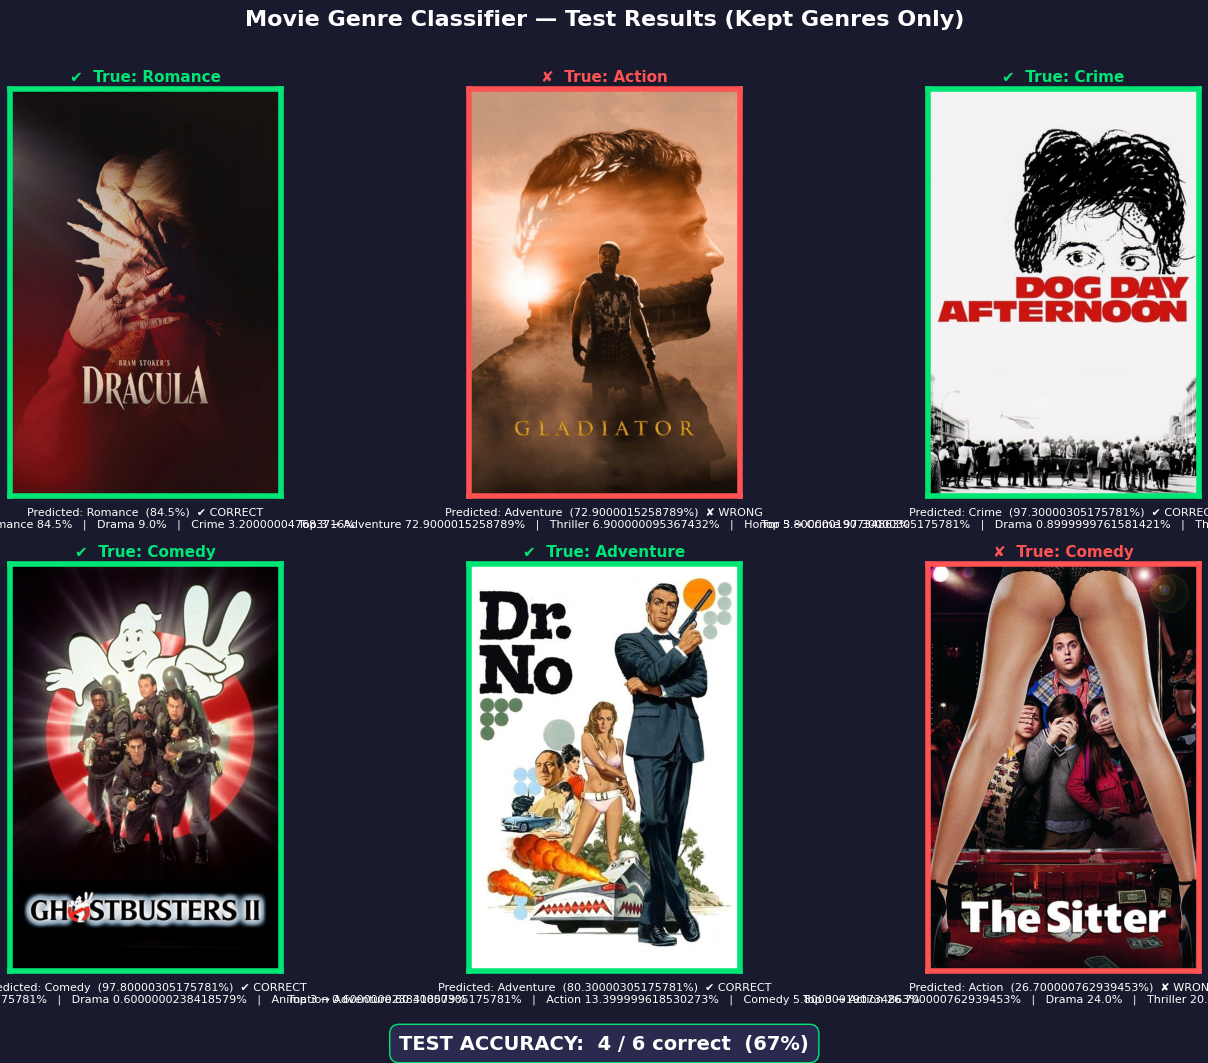

In [12]:
# ============================================================
# Model Tester — Fixed (filters dropped genres)
# ============================================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
CSV_PATH     = "movies_dataset.csv"
POSTERS_DIR  = Path("posters")
MODEL_SAVE   = "movie_genre_resnet50.pth"
CLASSES_SAVE = "genre_classes.txt"
IMG_SIZE     = 160
NUM_POSTERS  = 6

# ✅ Only genres the model was trained on (dropped ones removed)
KEPT_GENRES = {
    "Action", "Drama", "Comedy", "Horror",
    "Animation", "Adventure", "Thriller",
    "Crime", "Science Fiction", "Romance"
}

# ============================================================
# LOAD MODEL
# ============================================================
def load_model():
    with open(CLASSES_SAVE) as f:
        classes = [line.strip() for line in f if line.strip()]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"    Using device: {device}")

    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, len(classes)),
    )
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
    model.eval()
    model.to(device)

    return model, classes, device


# ============================================================
# PREDICT ONE IMAGE
# ============================================================
def predict(image_path, model, classes, device):
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    inp = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1).cpu().numpy()[0]

    top3_idx = np.argsort(probs)[::-1][:3]
    top3     = [(classes[i], round(probs[i] * 100, 1)) for i in top3_idx]
    return top3[0][0], top3[0][1], top3


# ============================================================
# BUILD LOOKUP — poster filename → genre
# ============================================================
def build_lookup(df):
    lookup = {}
    for _, row in df.iterrows():
        if pd.notna(row.get("poster_local")):
            filename = Path(str(row["poster_local"])).name.lower()
            lookup[filename] = row["main_genre"]
    return lookup


# ============================================================
# RUN TEST
# ============================================================
def run_test():
    print("Loading model...")
    model, classes, device = load_model()
    print(f"Model ready — {len(classes)} genres\n")

    # Load CSV
    df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["main_genre"] = df["genres"].apply(lambda x: str(x).split(",")[0].strip())

    # Build lookup
    lookup = build_lookup(df)
    print(f"CSV loaded — {len(lookup)} posters matched\n")

    # ✅ FIX: only pick posters whose genre is in KEPT_GENRES
    all_posters = [
        POSTERS_DIR / f for f in os.listdir(POSTERS_DIR)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Filter: keep only posters that belong to a kept genre
    filtered_posters = []
    for p in all_posters:
        filename   = p.name.lower()
        true_genre = lookup.get(filename, None)
        if true_genre and true_genre in KEPT_GENRES:
            filtered_posters.append(p)

    print(f"Posters after filtering dropped genres: {len(filtered_posters)}")

    if len(filtered_posters) == 0:
        print("❌ No valid posters found! Check your KEPT_GENRES or CSV poster_local column.")
        return

    chosen = random.sample(filtered_posters, min(NUM_POSTERS, len(filtered_posters)))

    # ── Plot: 2 rows × 3 cols ────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor("#1a1a2e")
    fig.suptitle("Movie Genre Classifier — Test Results (Kept Genres Only)",
                 color="white", fontsize=16, fontweight="bold", y=1.01)

    axes      = axes.flatten()
    correct   = 0
    has_labels = 0
    results   = []

    for i, poster_path in enumerate(chosen):
        predicted, confidence, top3 = predict(poster_path, model, classes, device)

        filename   = poster_path.name.lower()
        true_genre = lookup.get(filename, None)

        results.append((poster_path, predicted, confidence, top3, true_genre))

        ax  = axes[i]
        img = Image.open(poster_path).convert("RGB")
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

        if true_genre is None:
            border      = "#888888"
            label_text  = "True: Not in CSV"
            label_color = "#aaaaaa"
        elif predicted.lower() == true_genre.lower():
            border      = "#00e676"
            label_text  = f"✔  True: {true_genre}"
            label_color = "#00e676"
            correct    += 1
            has_labels += 1
        else:
            border      = "#ff5252"
            label_text  = f"✘  True: {true_genre}"
            label_color = "#ff5252"
            has_labels += 1

        for spine in ax.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(4)
            spine.set_visible(True)

        ax.set_title(label_text, color=label_color,
                     fontsize=11, fontweight="bold", pad=6)

        top3_str   = "   |   ".join([f"{g} {c}%" for g, c in top3])
        result_str = ""
        if true_genre:
            result_str = "✔ CORRECT" if predicted.lower() == true_genre.lower() else "✘ WRONG"

        ax.set_xlabel(
            f"Predicted: {predicted}  ({confidence}%)  {result_str}\nTop 3 → {top3_str}",
            color="white", fontsize=8, labelpad=8
        )

    # ── Accuracy summary ─────────────────────────────────────
    if has_labels > 0:
        acc     = correct / has_labels * 100
        summary = f"TEST ACCURACY:  {correct} / {has_labels} correct  ({acc:.0f}%)"
        box_col = "#00e676" if acc >= 50 else "#ff5252"
    else:
        acc     = None
        summary = "No labels found — check poster_local column in CSV"
        box_col = "#888888"

    fig.text(0.5, -0.03, summary,
             ha="center", color="white", fontsize=14, fontweight="bold",
             bbox=dict(facecolor="#2a2a4e", edgecolor=box_col,
                       boxstyle="round,pad=0.5"))

    plt.tight_layout()
    plt.savefig("test_results.png", dpi=120, bbox_inches="tight",
                facecolor=fig.get_facecolor())

    # ── Terminal output ──────────────────────────────────────
    print("\n" + "=" * 70)
    for poster_path, predicted, confidence, _, true_genre in results:
        true_str = true_genre if true_genre else "Unknown"
        if true_genre:
            result = "✔ CORRECT" if predicted.lower() == true_genre.lower() else "✘ WRONG"
        else:
            result = "? NO LABEL"
        print(f"  {poster_path.name[:30]:<30} | True: {true_str:<15} | Pred: {predicted:<15} | {result}")
    print("=" * 70)

    if has_labels > 0:
        print(f"\n  TEST ACCURACY: {correct}/{has_labels} = {acc:.0f}%\n")

    print("  Saved → test_results.png")
    plt.show()


run_test()

In [1]:
import subprocess
import sys
import platform

print("=" * 50)
print("       GPU DETECTION TEST")
print("=" * 50)

# Check PyTorch
print("\n[1] PyTorch / CUDA")
try:
    import torch
    print(f"    PyTorch version : {torch.__version__}")
    print(f"    CUDA available  : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            print(f"    GPU [{i}] : {torch.cuda.get_device_name(i)}")
    else:
        print("    No CUDA GPU detected.")
except ImportError:
    print("    PyTorch not installed → pip install torch")

# Check nvidia-smi
print("\n[2] nvidia-smi")
try:
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total",
         "--format=csv,noheader"],
        capture_output=True, text=True, timeout=10
    )
    if result.returncode == 0 and result.stdout.strip():
        for i, line in enumerate(result.stdout.strip().split("\n")):
            print(f"    GPU [{i}] : {line.strip()}")
    else:
        print("    No NVIDIA GPU found.")
except FileNotFoundError:
    print("    nvidia-smi not found.")

# Python info
print("\n[3] Python Info")
print(f"    Python  : {sys.version.split()[0]}")
print(f"    OS      : {platform.system()} {platform.release()}")
print("=" * 50)

       GPU DETECTION TEST

[1] PyTorch / CUDA
    PyTorch version : 2.11.0+cpu
    CUDA available  : False
    No CUDA GPU detected.

[2] nvidia-smi
    GPU [0] : Quadro T1000, 4096 MiB

[3] Python Info
    Python  : 3.13.5
    OS      : Windows 11
